In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ast import literal_eval
import seaborn as sns

# Đọc file CSV
df_pairs = pd.read_csv('../../data/clean/clean_resumes_v2.csv')

print(f"Số lượng Candidate Resumes và JD: {len(df_pairs)}")

Số lượng Candidate Resumes và JD: 1193700


In [2]:
df_pairs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193700 entries, 0 to 1193699
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   cr_id                 1193700 non-null  object
 1   jd_id                 1193700 non-null  object
 2   cr_category           1193700 non-null  object
 3   jd_name               1193700 non-null  object
 4   primary_skills_jd     1193700 non-null  object
 5   secondary_skills_jd   1193700 non-null  object
 6   adjectives_jd         1193700 non-null  object
 7   adverbs_jd            1193700 non-null  object
 8   primary_skills_cr     1193700 non-null  object
 9   secondary_skills_cr   1193700 non-null  object
 10  adjectives_cr         1193700 non-null  object
 11  adverbs_cr            1193700 non-null  object
 12  adjectives_weight_cr  1193700 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 118.4+ MB


In [3]:

# Hàm chuyển đổi an toàn: xử lý cả chuỗi và danh sách
def safe_literal_eval(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    try:
        return literal_eval(val)
    except (ValueError, SyntaxError):
        return []
def jaccard_similarity(list1, list2):
    def normalize_tokens(lst):
        return set([str(x).strip().lower() for x in lst if str(x).strip()])

    set1, set2 = normalize_tokens(list1), normalize_tokens(list2)

    set1, set2 = set(list1), set(list2)
    return len(set1 & set2) / len(set1 | set2) if set1 | set2 else 0

def assign_suitability(score):
    if score > 0.6:
        return 'Most Suitable'          # Top 25%
    elif score > 0.1:
        return 'Moderately Suitable'    # Khoảng giữa
    else:
        return 'Not Suitable'




In [4]:
print(jaccard_similarity(['python'],['python']))

1.0


In [5]:
pd.DataFrame(df_pairs)

,cr_id,jd_id,cr_category,jd_name,primary_skills_jd,secondary_skills_jd,adjectives_jd,adverbs_jd,primary_skills_cr,secondary_skills_cr,adjectives_cr,adverbs_cr,adjectives_weight_cr
0,CANDIDATE_0,JOB_0,Data Science,MLops Engineer,"['python', 'java', 'javascript', 'c++', 'tenso...","['computer vision', 'backend', 'mobile', 'data...","['qualified', 'familiar', 'digital', 'primary'...",[],"['python', 'git', 'javascript', 'docker', 'jav...","['plotly', 'pipeline', 'random forest', 'monit...","['redundant', 'negative', 'neural', 'past', 's...","['plotly', 'personally', 'well', 'frequently']",37
1,CANDIDATE_0,JOB_1,Data Science,"Senior DevOps Engineer (Cloud, AWS)","['python', 'bash', 'aws', 'ci cd', 'devops', '...","['automation', 'aws', 'software', 'devops', 'd...","['agile', 'professional', 'rapid', 'experience...","['occasionally', 'quickly', 'independently', '...","['git', 'systems', 'docker', 'python']","['plotly', 'pipeline', 'random forest', 'monit...","['redundant', 'negative', 'neural', 'past', 's...","['plotly', 'personally', 'well', 'frequently']",37
2,CANDIDATE_0,JOB_2,Data Science,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),"['software', 'sales']","['software', 'network', 'project manager']","['digital', 'important', 'smart', 'urban', 'lo...","['currently', 'clearly', 'directly']",[],"['plotly', 'python', 'pipeline', 'random fores...","['redundant', 'negative', 'neural', 'past', 's...","['plotly', 'personally', 'well', 'frequently']",37
3,CANDIDATE_0,JOB_4,Data Science,"VHT - Embedded Software Engineer (Linux, C++)",['linux'],"['mobile', 'network', 'security', 'embedded', ...","['optical', 'high', 'core', 'military', 'vietn...",[],[],"['plotly', 'python', 'pipeline', 'random fores...","['redundant', 'negative', 'neural', 'past', 's...","['plotly', 'personally', 'well', 'frequently']",37
4,CANDIDATE_0,JOB_5,Data Science,Quality Assurance Manager (QAM),"['cicd', 'power bi', 'software', 'qa', 'produc...","['cicd', 'power bi', 'software', 'qa', 'produc...","['agile', 'internal', 'multiple', 'commercial'...","['internationally', 'proficiently']",['qa'],"['plotly', 'python', 'pipeline', 'random fores...","['redundant', 'negative', 'neural', 'past', 's...","['plotly', 'personally', 'well', 'frequently']",37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193695,CANDIDATE_825,JOB_2505,DotNet Developer,Nhân Viên Thiết Kế Đồ Họa/ Graphic Designer,"['software', 'illustrator', 'photoshop']","['designer', 'sales', 'illustrator', 'photoshop']","['offline', 'short', 'practical', 'online', 'g...","['right', 'closely', 'independently']",[],"['sql server', 'sql', 'html', 'css']","['intra', 'english', 'semi', 'net', 'cultural']",[],5
1193696,CANDIDATE_825,JOB_2506,DotNet Developer,Graphic & Motion Designer,"['illustrator', 'photoshop', 'adobe photoshop'...","['illustrator', 'photoshop']","['high', 'official', 'annual', 'equivalent', '...","['right', 'online']",[],"['sql server', 'sql', 'html', 'css']","['intra', 'english', 'semi', 'net', 'cultural']",[],5
1193697,CANDIDATE_825,JOB_2507,DotNet Developer,Chuyên Graphic Designer,"['illustrator', 'photoshop']",['designer'],"['artistic', 'relevant', 'dynamic', 'right', '...","['right', 'online', 'proficiently']",[],"['sql server', 'sql', 'html', 'css']","['intra', 'english', 'semi', 'net', 'cultural']",[],5
1193698,CANDIDATE_825,JOB_2510,DotNet Developer,Nhân Viên Thiết Kế Đồ Họa,"['software', 'typography', 'illustrator', 'pho...",['sales'],"['offline', 'practical', 'lunchompany', 'dynam...","['right', 'online', 'closely', 'independently'...",[],"['sql server', 'sql', 'html', 'css']","['intra', 'english', 'semi', 'net', 'cultural']",[],5


In [6]:
import ast
def to_list_safe(val):
    """Trả về list; chấp nhận list thật, NaN, hoặc chuỗi '[...]'."""
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    val = str(val).strip()
    if val.startswith('[') and val.endswith(']'):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    if val == '':
        return []
    return [v.strip() for v in val.split('|')]  # Fallback: chuỗi 'python|sql'

def to_set_lower(lst):
    """Chuyển list → frozenset token lowercase, bỏ rỗng."""
    return frozenset(str(x).strip().lower() for x in lst if str(x).strip())
def to_set_lower(lst):
    """Chuyển list → frozenset token lowercase, bỏ rỗng."""
    return frozenset(str(x).strip().lower() for x in lst if str(x).strip())

def jaccard(a, b):
    """Tính Jaccard cho hai tập hợp (hoặc list)."""
    if not a and not b:
        return 0.0
    if not isinstance(a, set):
        a = set(a)
    if not isinstance(b, set):
        b = set(b)
    return len(a & b) / len(a | b)

In [7]:
list_cols = [ 
    'primary_skills_jd', 'secondary_skills_jd', 'adjectives_jd', 'adverbs_jd',
    'primary_skills_cr', 'secondary_skills_cr', 'adjectives_cr', 'adverbs_cr'
]

for col in list_cols:
    df_pairs[col]      = df_pairs[col].apply(to_list_safe)
    df_pairs[col + '_set'] = df_pairs[col].apply(to_set_lower)

In [8]:
df_pairs['primary_sim'] = [
    jaccard(a, b) for a, b in zip(df_pairs['primary_skills_jd_set'],
                                  df_pairs['primary_skills_cr_set'])
]

df_pairs['secondary_sim'] = [
    jaccard(a, b) for a, b in zip(df_pairs['secondary_skills_jd_set'],
                                  df_pairs['secondary_skills_cr_set'])
]

df_pairs['adj_sim'] = [
    jaccard(a, b) for a, b in zip(df_pairs['adjectives_jd_set'],
                                  df_pairs['adjectives_cr_set'])
]

In [9]:
df_pairs['adj_weight'] = df_pairs['adjectives_weight_cr'].fillna(
    df_pairs['adjectives_cr_set'].apply(len)
)

df_pairs['total_similarity'] = (
    df_pairs['primary_sim']
  + df_pairs['secondary_sim']
  + df_pairs['adj_sim'] * np.log1p(df_pairs['adj_weight'])
)

df_pairs['suitability'] = np.select(
    [df_pairs['total_similarity'] >= 0.6 ,
     df_pairs['total_similarity'] >= 0.3],
    ['Most Suitable', 'Moderately Suitable'],
    default='Not Suitable'
)

In [10]:
np.log1p(7)

np.float64(2.0794415416798357)

In [11]:
df_similarity = df_pairs.drop_duplicates(subset=[
    'primary_sim',
    'secondary_sim',
    'adj_sim',
    'adj_weight',
])


In [12]:
df_similarity = df_similarity.drop_duplicates(subset=['jd_id', 'cr_id'])
# Reset index nếu muốn
df_similarity.reset_index(drop=True, inplace=True)

In [13]:
pd.DataFrame(df_similarity)

,cr_id,jd_id,cr_category,jd_name,primary_skills_jd,secondary_skills_jd,adjectives_jd,adverbs_jd,primary_skills_cr,secondary_skills_cr,...,primary_skills_cr_set,secondary_skills_cr_set,adjectives_cr_set,adverbs_cr_set,primary_sim,secondary_sim,adj_sim,adj_weight,total_similarity,suitability
0,CANDIDATE_0,JOB_0,Data Science,MLops Engineer,"[python, java, javascript, c++, tensorflow, py...","[computer vision, backend, mobile, data scient...","[qualified, familiar, digital, primary, great,...",[],"[python, git, javascript, docker, java, machin...","[plotly, pipeline, random forest, monitoring, ...",...,"(python, docker, java, machine learning, compu...","(sql, numpy, jquery, knn, kibana, kafka, datab...","(young, neural, neutral, random, meta, red, an...","(personally, plotly, frequently, well)",0.500000,0.000000,0.000000,37,0.500000,Moderately Suitable
1,CANDIDATE_0,JOB_1,Data Science,"Senior DevOps Engineer (Cloud, AWS)","[python, bash, aws, ci cd, devops, devops engi...","[automation, aws, software, devops, devops eng...","[agile, professional, rapid, experienced, tech...","[occasionally, quickly, independently, effecti...","[git, systems, docker, python]","[plotly, pipeline, random forest, monitoring, ...",...,"(python, docker, git, systems)","(sql, numpy, jquery, knn, kibana, kafka, datab...","(young, neural, neutral, random, meta, red, an...","(personally, plotly, frequently, well)",0.173913,0.047619,0.016393,37,0.281165,Not Suitable
2,CANDIDATE_0,JOB_2,Data Science,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),"[software, sales]","[software, network, project manager]","[digital, important, smart, urban, logical, sp...","[currently, clearly, directly]",[],"[plotly, python, pipeline, random forest, moni...",...,(),"(sql, numpy, jquery, knn, kibana, kafka, datab...","(young, neural, neutral, random, meta, red, an...","(personally, plotly, frequently, well)",0.000000,0.000000,0.000000,37,0.000000,Not Suitable
3,CANDIDATE_0,JOB_4,Data Science,"VHT - Embedded Software Engineer (Linux, C++)",[linux],"[mobile, network, security, embedded, systems]","[optical, high, core, military, vietnamese, go...",[],[],"[plotly, python, pipeline, random forest, moni...",...,(),"(sql, numpy, jquery, knn, kibana, kafka, datab...","(young, neural, neutral, random, meta, red, an...","(personally, plotly, frequently, well)",0.000000,0.048780,0.020000,37,0.121532,Not Suitable
4,CANDIDATE_0,JOB_5,Data Science,Quality Assurance Manager (QAM),"[cicd, power bi, software, qa, production, svn...","[cicd, power bi, software, qa, production, com...","[agile, internal, multiple, commercial, organi...","[internationally, proficiently]",[qa],"[plotly, python, pipeline, random forest, moni...",...,(qa),"(sql, numpy, jquery, knn, kibana, kafka, datab...","(young, neural, neutral, random, meta, red, an...","(personally, plotly, frequently, well)",0.111111,0.000000,0.021277,37,0.188507,Not Suitable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34028,CANDIDATE_825,JOB_2200,DotNet Developer,Senior Full-Stack Engineering Manager,"[backend, frontend]","[javascript, c#, ui ux, sql, azure sql, automa...","[agile, japanese, modern, friendly, different,...","[consistently, effectively, newly, onboard, of...",[],"[sql server, sql, html, css]",...,(),"(html, css, sql, sql server)","(english, semi, net, intra, cultural)",(),0.000000,0.035714,0.013889,5,0.060600,Not Suitable
34029,CANDIDATE_825,JOB_2272,DotNet Developer,Technical Leader (Cobol Techlead),[cobol],"[python, java, c#, cobol, spring boot, sql, aw...","[modern, internal, professional, equivalent, k...","[right, online, effectively, seamlessly]",[],"[sql server, sql, html, css]",...,(),"(html, css, sql, sql server)","(english, semi, net, intra, cultural)",(),0.000000,0.071429,0.033333,5,0.131154,Not Suitable
34030,CANDIDATE_825,JOB_2320,DotNet Developer,Bridge Software Engineer - Remote,"[python, java, sql, nosql, software, database]","[python, java, javascript, golang, reac

In [14]:
df_similarity.describe()

,adjectives_weight_cr,primary_sim,secondary_sim,adj_sim,adj_weight,total_similarity
count,34033.000000,34033.000000,34033.000000,34033.000000,34033.000000,34033.000000
mean,25.758940,0.236780,0.061653,0.044707,25.758940,0.437266
std,17.014087,0.304464,0.065896,0.032543,17.014087,0.320542
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,0.000000,0.000000,0.023810,16.000000,0.206022
50%,22.000000,0.142857,0.052632,0.040000,22.000000,0.344062
75%,33.000000,0.333333,0.090909,0.062500,33.000000,0.565759
max,79.000000,1.000000,1.000000,0.333333,79.000000,2.010689


In [15]:
df_similarity.drop(columns=[c + '_set' for c in list_cols], inplace=True)

In [16]:
df_similarity.dropna(inplace=True)

In [17]:
df_similarity.to_csv('../csv/jd_cr_similarity.csv', index=False)

In [18]:
df_similarity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34033 entries, 0 to 34032
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cr_id                 34033 non-null  object 
 1   jd_id                 34033 non-null  object 
 2   cr_category           34033 non-null  object 
 3   jd_name               34033 non-null  object 
 4   primary_skills_jd     34033 non-null  object 
 5   secondary_skills_jd   34033 non-null  object 
 6   adjectives_jd         34033 non-null  object 
 7   adverbs_jd            34033 non-null  object 
 8   primary_skills_cr     34033 non-null  object 
 9   secondary_skills_cr   34033 non-null  object 
 10  adjectives_cr         34033 non-null  object 
 11  adverbs_cr            34033 non-null  object 
 12  adjectives_weight_cr  34033 non-null  int64  
 13  primary_sim           34033 non-null  float64
 14  secondary_sim         34033 non-null  float64
 15  adj_sim            

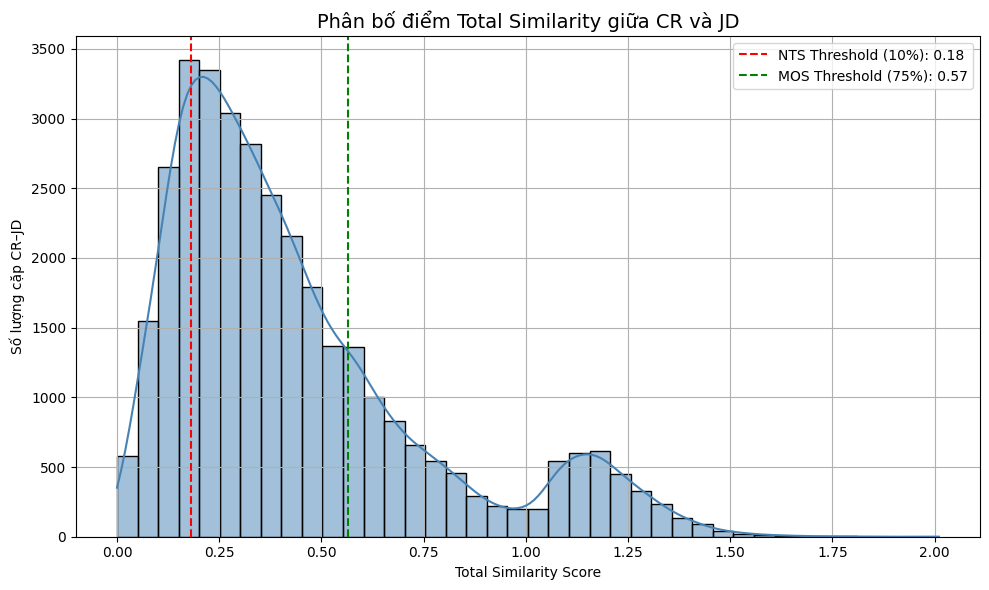

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kiểu đồ họa
plt.figure(figsize=(10, 6))
sns.histplot(df_similarity['total_similarity'], bins=40, kde=True, color='steelblue')

# Đánh dấu phân vị nếu bạn dùng để gán nhãn
threshold_nts = df_similarity['total_similarity'].quantile(0.2)
threshold_mos = df_similarity['total_similarity'].quantile(0.75)

# Vẽ đường phân biệt ngưỡng suitability
plt.axvline(threshold_nts, color='red', linestyle='--', label=f'NTS Threshold (10%): {threshold_nts:.2f}')
plt.axvline(threshold_mos, color='green', linestyle='--', label=f'MOS Threshold (75%): {threshold_mos:.2f}')

plt.title('Phân bố điểm Total Similarity giữa CR và JD', fontsize=14)
plt.xlabel('Total Similarity Score')
plt.ylabel('Số lượng cặp CR–JD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Phân bố nhãn Suitability:
suitability
Not Suitable           14498
Moderately Suitable    11947
Most Suitable           7588
Name: count, dtype: int64

Tổng số cặp JD-CR: 34033


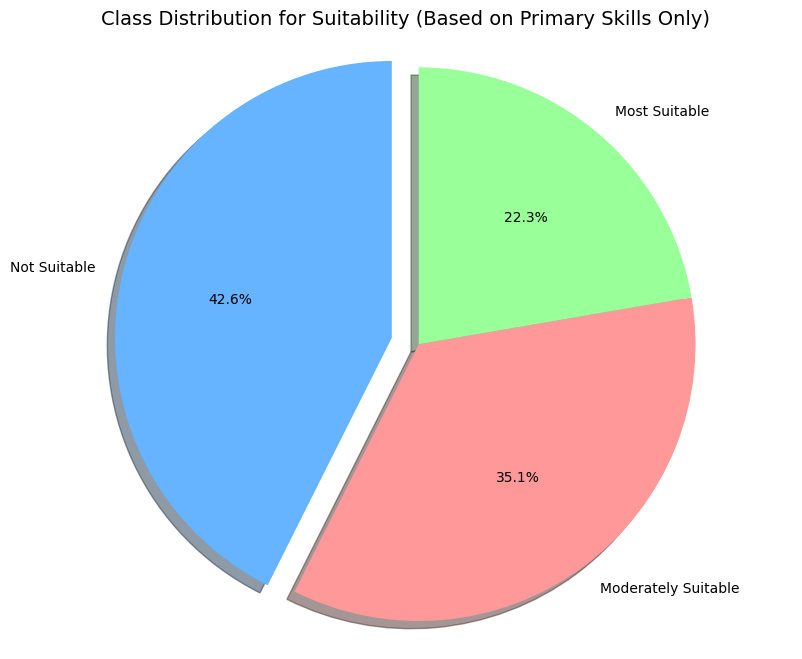


=== SUMMARY ===
Total similarity pairs: 34033
Match rate: 0.00%
Neutral rate: 0.00%
Mismatch rate: 0.00%


In [20]:

# Kiểm tra phân bố nhãn
class_counts = df_similarity['suitability'].value_counts()
print("\nPhân bố nhãn Suitability:")
print(class_counts)
print(f"\nTổng số cặp JD-CR: {len(df_similarity)}")


# Tạo explode động cho biểu đồ
labels = class_counts.index
sizes = class_counts.values
colors = ['#66b3ff', '#ff9999', '#99ff99'][:len(labels)]
explode = [0.1 if i == 0 else 0 for i in range(len(labels))]

# Vẽ biểu đồ tròn
plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Class Distribution for Suitability (Based on Primary Skills Only)', fontsize=14)
plt.axis('equal')
plt.savefig('class_distribution_suitability.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== SUMMARY ===")
print(f"Total similarity pairs: {len(df_similarity)}")
print(f"Match rate: {(class_counts.get('Match', 0) / len(df_similarity) * 100):.2f}%")
print(f"Neutral rate: {(class_counts.get('Neutral', 0) / len(df_similarity) * 100):.2f}%")
print(f"Mismatch rate: {(class_counts.get('Mismatch', 0) / len(df_similarity) * 100):.2f}%")

In [21]:
df_similarity['suitability'] = df_similarity['suitability'].map({
    'Not Suitable': 0,
    'Moderately Suitable': 1,
    'Most Suitable': 2
})


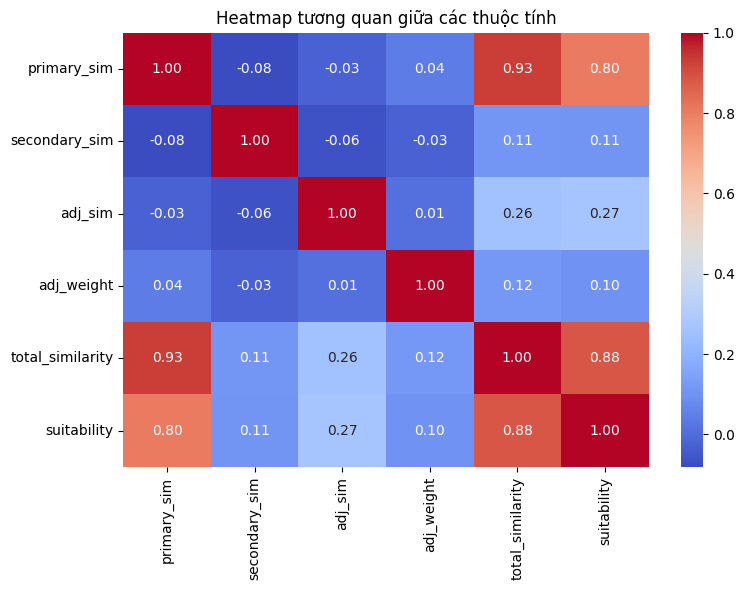

In [22]:
corr = df_similarity[['primary_sim', 'secondary_sim', 'adj_sim', 'adj_weight', 'total_similarity','suitability']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap tương quan giữa các thuộc tính")
plt.tight_layout()
plt.show()


In [23]:
df_similarity = pd.read_csv('../csv/jd_cr_similarity.csv')

In [24]:
df_similarity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34033 entries, 0 to 34032
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cr_id                 34033 non-null  object 
 1   jd_id                 34033 non-null  object 
 2   cr_category           34033 non-null  object 
 3   jd_name               34033 non-null  object 
 4   primary_skills_jd     34033 non-null  object 
 5   secondary_skills_jd   34033 non-null  object 
 6   adjectives_jd         34033 non-null  object 
 7   adverbs_jd            34033 non-null  object 
 8   primary_skills_cr     34033 non-null  object 
 9   secondary_skills_cr   34033 non-null  object 
 10  adjectives_cr         34033 non-null  object 
 11  adverbs_cr            34033 non-null  object 
 12  adjectives_weight_cr  34033 non-null  int64  
 13  primary_sim           34033 non-null  float64
 14  secondary_sim         34033 non-null  float64
 15  adj_sim            

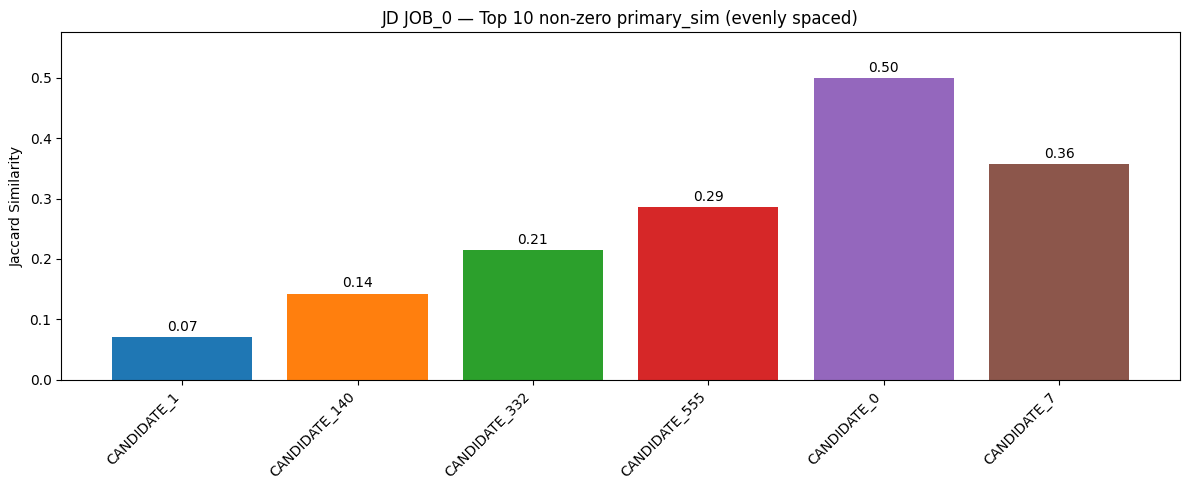

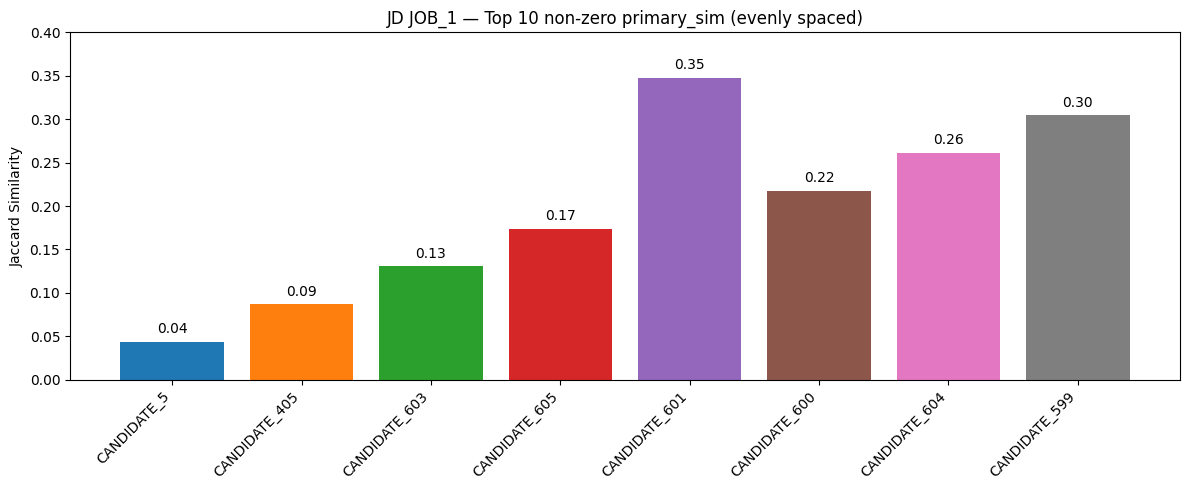

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

jd_ids = ['JOB_0', 'JOB_1']
results = []

TARGET = 10          # số cột muốn vẽ

for jd_id in jd_ids:
    subset = df_similarity.query("jd_id == @jd_id and primary_sim > 0") \
                           [['cr_id', 'primary_sim']] \
                           .sort_values('primary_sim')

    if len(subset) < TARGET:
        print(f"JD {jd_id} chỉ có {len(subset)} CR >0; bỏ qua.")
        continue

    # Chọn 10 chỉ số cách đều (linspace) trong range 0..len-1
    idx = np.linspace(0, len(subset)-1, TARGET, dtype=int)
    picked = subset.iloc[idx]

    # Nếu trùng primary_sim ⇒ loại trùng và bổ sung CR kế tiếp
    picked = picked.drop_duplicates('primary_sim')
    cursor  = 0
    while len(picked) < TARGET and cursor < len(subset):
        cand = subset.iloc[cursor]
        if cand['primary_sim'] not in picked['primary_sim'].values:
            picked = pd.concat([picked, cand.to_frame().T])
        cursor += 1

    picked['jd_id'] = jd_id
    results.append(picked)

# Gộp
df_plot = pd.concat(results, ignore_index=True)

# ─────── Vẽ ───────
colors = plt.cm.tab10.colors               # 10 màu khác nhau
for jd_id, grp in df_plot.groupby('jd_id'):
    plt.figure(figsize=(12, 5))
    plt.bar(grp['cr_id'], grp['primary_sim'], color=colors[:len(grp)])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Jaccard Similarity')
    plt.title(f'JD {jd_id} — Top 10 non‑zero primary_sim (evenly spaced)')
    for i, v in enumerate(grp['primary_sim']):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.ylim(0, grp['primary_sim'].max()*1.15)
    plt.tight_layout()
    plt.show()


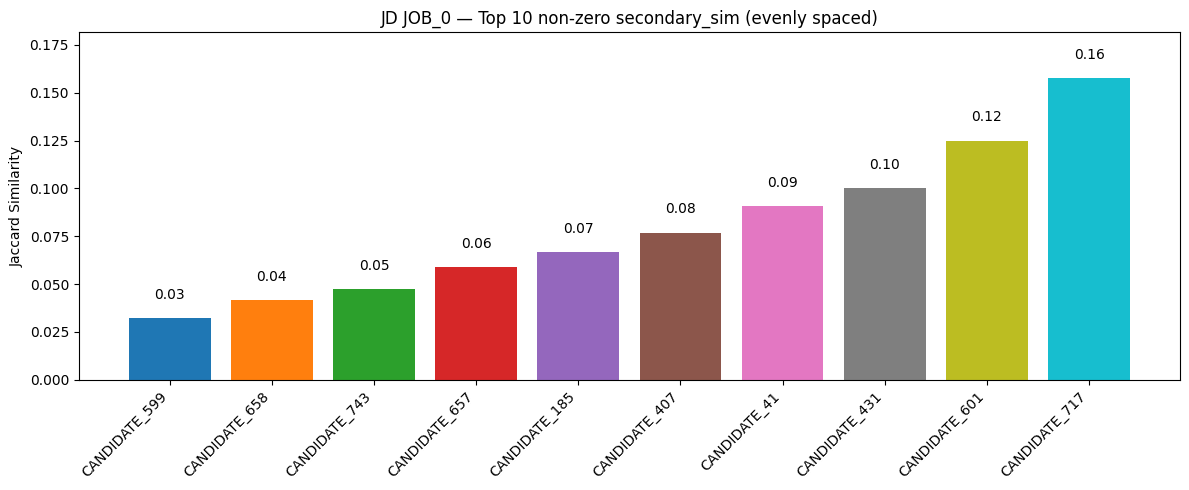

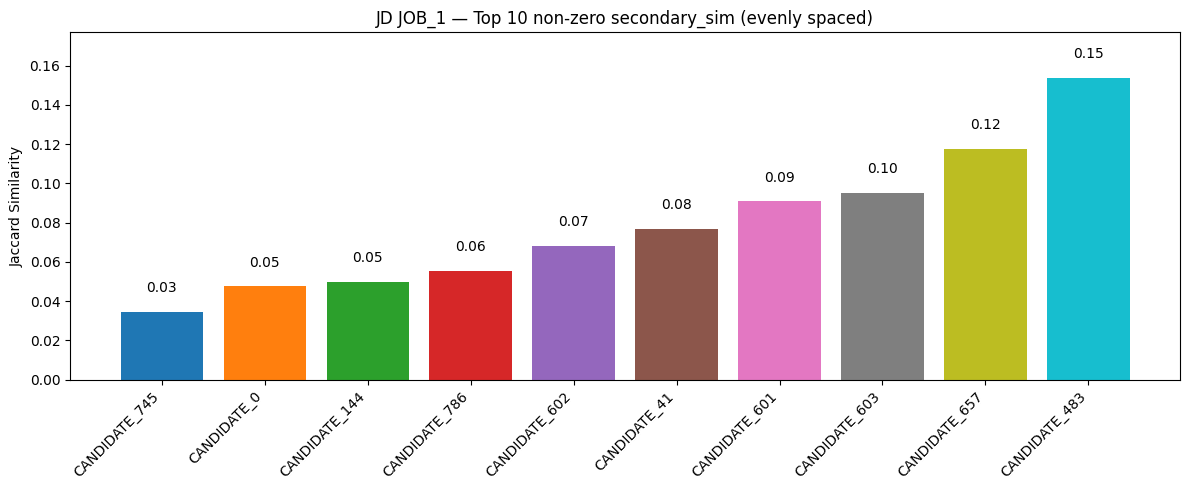

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

jd_ids = ['JOB_0', 'JOB_1']
results = []

TARGET = 10          # số cột muốn vẽ

for jd_id in jd_ids:
    subset = df_similarity.query("jd_id == @jd_id and secondary_sim > 0") \
                           [['cr_id', 'secondary_sim']] \
                           .sort_values('secondary_sim')

    if len(subset) < TARGET:
        print(f"JD {jd_id} chỉ có {len(subset)} CR >0; bỏ qua.")
        continue

    # Chọn 10 chỉ số cách đều (linspace) trong range 0..len-1
    idx = np.linspace(0, len(subset)-1, TARGET, dtype=int)
    picked = subset.iloc[idx]

    # Nếu trùng secondary_sim ⇒ loại trùng và bổ sung CR kế tiếp
    picked = picked.drop_duplicates('secondary_sim')
    cursor  = 0
    while len(picked) < TARGET and cursor < len(subset):
        cand = subset.iloc[cursor]
        if cand['secondary_sim'] not in picked['secondary_sim'].values:
            picked = pd.concat([picked, cand.to_frame().T])
        cursor += 1

    picked['jd_id'] = jd_id
    results.append(picked)

# Gộp
df_plot = pd.concat(results, ignore_index=True)

# ─────── Vẽ ───────
colors = plt.cm.tab10.colors               # 10 màu khác nhau
for jd_id, grp in df_plot.groupby('jd_id'):
    plt.figure(figsize=(12, 5))
    plt.bar(grp['cr_id'], grp['secondary_sim'], color=colors[:len(grp)])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Jaccard Similarity')
    plt.title(f'JD {jd_id} — Top 10 non‑zero secondary_sim (evenly spaced)')
    for i, v in enumerate(grp['secondary_sim']):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.ylim(0, grp['secondary_sim'].max()*1.15)
    plt.tight_layout()
    plt.show()


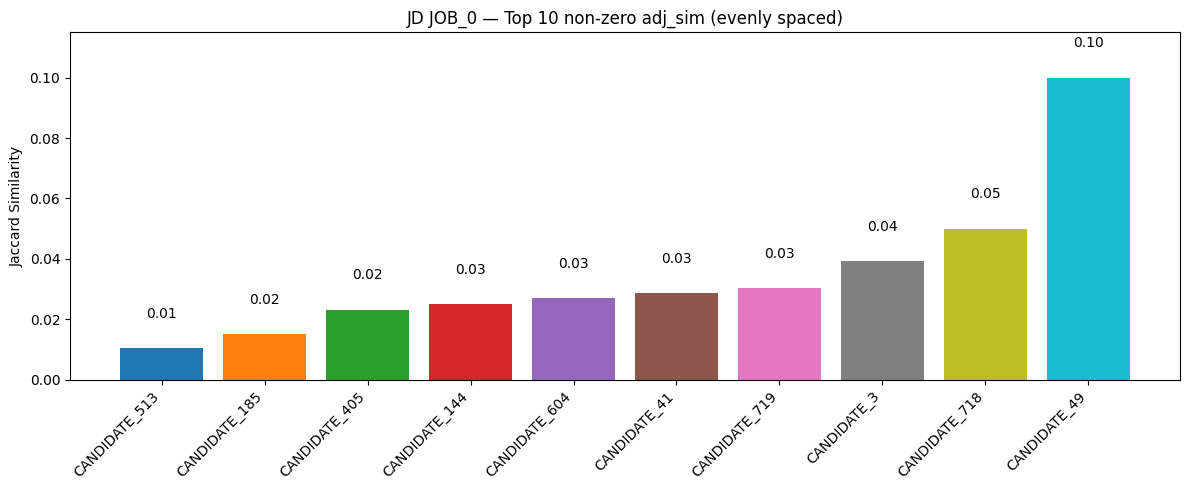

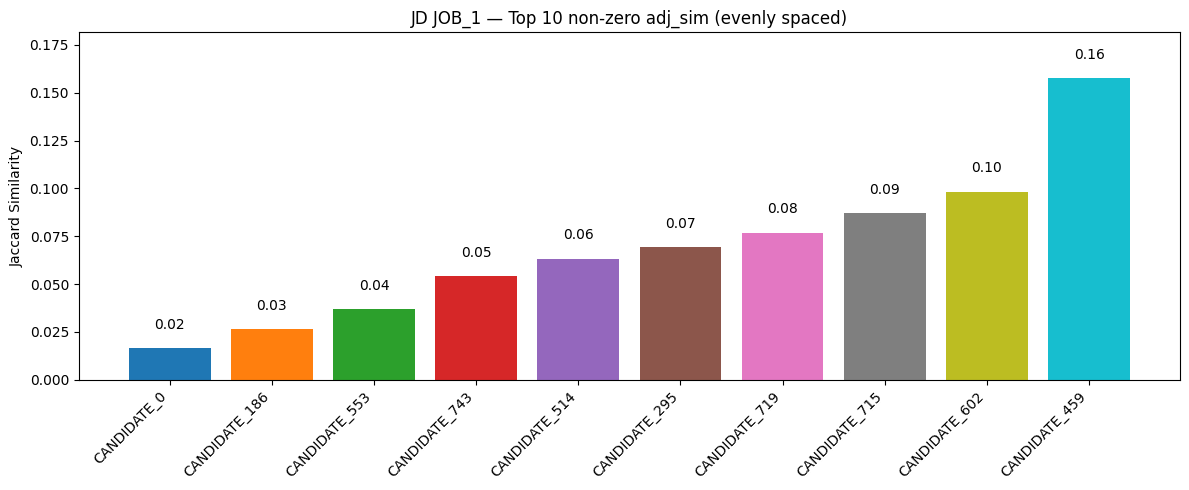

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

jd_ids = ['JOB_0', 'JOB_1']
results = []

TARGET = 10          # số cột muốn vẽ

for jd_id in jd_ids:
    subset = df_similarity.query("jd_id == @jd_id and adj_sim > 0") \
                           [['cr_id', 'adj_sim']] \
                           .sort_values('adj_sim')

    if len(subset) < TARGET:
        print(f"JD {jd_id} chỉ có {len(subset)} CR >0; bỏ qua.")
        continue

    # Chọn 10 chỉ số cách đều (linspace) trong range 0..len-1
    idx = np.linspace(0, len(subset)-1, TARGET, dtype=int)
    picked = subset.iloc[idx]

    # Nếu trùng adj_sim ⇒ loại trùng và bổ sung CR kế tiếp
    picked = picked.drop_duplicates('adj_sim')
    cursor  = 0
    while len(picked) < TARGET and cursor < len(subset):
        cand = subset.iloc[cursor]
        if cand['adj_sim'] not in picked['adj_sim'].values:
            picked = pd.concat([picked, cand.to_frame().T])
        cursor += 1

    picked['jd_id'] = jd_id
    results.append(picked)

# Gộp
df_plot = pd.concat(results, ignore_index=True)

# ─────── Vẽ ───────
colors = plt.cm.tab10.colors               # 10 màu khác nhau
for jd_id, grp in df_plot.groupby('jd_id'):
    plt.figure(figsize=(12, 5))
    plt.bar(grp['cr_id'], grp['adj_sim'], color=colors[:len(grp)])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Jaccard Similarity')
    plt.title(f'JD {jd_id} — Top 10 non‑zero adj_sim (evenly spaced)')
    for i, v in enumerate(grp['adj_sim']):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.ylim(0, grp['adj_sim'].max()*1.15)
    plt.tight_layout()
    plt.show()


In [28]:
print(df_similarity['suitability'].value_counts())
print(df_similarity['suitability'].value_counts(normalize=True))


suitability
Not Suitable           14498
Moderately Suitable    11947
Most Suitable           7588
Name: count, dtype: int64
suitability
Not Suitable           0.425998
Moderately Suitable    0.351042
Most Suitable          0.222960
Name: proportion, dtype: float64


In [29]:
import pandas as pd
import numpy as np
import ast

# ---------------- 0) Hàm tiện ích -----------------
def ensure_list(x):
    """Bảo đảm x luôn là list; nếu là chuỗi '[...]' thì literal_eval."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        parsed = ast.literal_eval(str(x))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [str(x)]

# ---------------- 1) Ánh xạ suitability <‑> class ---------------
suitability_to_class = {0: "Not Suitable", 1: "Moderately Suitable", 2: "Most Suitable"}
class_to_suitability = {v: k for k, v in suitability_to_class.items()}

# ---------------- 2) Danh sách CR và lớp mong muốn --------------
cr_list = [
    "CANDIDATE_714", "CANDIDATE_2", "CANDIDATE_3", "CANDIDATE_88",  # Most Suitable
    "CANDIDATE_5", "CANDIDATE_6", "CANDIDATE_7", "CANDIDATE_8",  # Moderately Suitable
    "CANDIDATE_9", "CANDIDATE_140"                            # Not Suitable
]
class_map_by_cr = (
    {cr: "Most Suitable" for cr in cr_list[:4]} |
    {cr: "Moderately Suitable" for cr in cr_list[4:8]} |
    {cr: "Not Suitable" for cr in cr_list[8:]}
)

# ---------------- 3) Chuẩn bị df_pairs_1 ------------------------
df_pairs_1 = df_similarity.copy()
df_pairs_1["class"] = df_pairs_1["suitability"].map(suitability_to_class)

for col in ["primary_skills_cr", "primary_skills_jd"]:
    df_pairs_1[col] = df_pairs_1[col].apply(ensure_list)

def fallback_chain(target_val: int):
    return {2: [1, 0], 1: [2, 0], 0: [1, 2]}[target_val]

# ---------------- 5) Lấy 5 JD cho mỗi CR -----------------------
rows = []
rng = np.random.default_rng(seed=42)  # để kết quả tái lập

for cr in cr_list:
    lbl = class_map_by_cr[cr]                       # "Most Suitable"/"Moderately Suitable"/"Not Suitable"
    target = class_to_suitability[lbl]              # 2/1/0

    # 5a. Ưu tiên JD đúng lớp
    mask_target = (df_pairs_1["cr_id"] == cr) & (df_pairs_1["suitability"] == target)
    picked = df_pairs_1[mask_target].sample(
        n=min(5, mask_target.sum()),
        random_state=rng.integers(1e9)
    ) if mask_target.any() else pd.DataFrame()

    # 5b. Fallback nếu chưa đủ
    while len(picked) < 5:
        for fb in fallback_chain(target):
            exclude = picked["jd_id"].tolist() if "jd_id" in picked else []

            remain = df_pairs_1[
                (df_pairs_1["cr_id"] == cr) &
                (df_pairs_1["suitability"] == fb) &
                (~df_pairs_1["jd_id"].isin(exclude))
            ]

            if remain.empty:
                continue

            need = 5 - len(picked)
            add = remain.sample(
                n=min(need, len(remain)),
                random_state=rng.integers(1e9)
            )
            picked = pd.concat([picked, add], ignore_index=True)

            if len(picked) == 5:
                break
        else:
            raise ValueError(f"{cr}: không đủ 5 JD dù đã fallback")


    # 5c. Giữ cột cần thiết & tính matched_primary_skills
    picked = picked[[
        "cr_id", "jd_id",
        "primary_skills_cr", "primary_skills_jd",
        "total_similarity"
    ]].assign(**{"class": lbl})

    picked["matched_primary_skills"] = picked.apply(
        lambda r: list(set(r["primary_skills_cr"]) & set(r["primary_skills_jd"])),
        axis=1
    )

    rows.append(picked)

# ---------------- 6) Gộp kết quả & thêm id ----------------------
df_out = pd.concat(rows, ignore_index=True)
df_out.insert(0, "id", df_out.index + 1)

# ---------------- 7) Hiển thị -------------------------------
print(df_out.head(10))
print("Tổng số dòng:", len(df_out))   # 10 CR × 5 JD = 50


ValueError: CANDIDATE_714: không đủ 5 JD dù đã fallback

In [10]:
print(df_pairs_1.columns.tolist())

['cr_id', 'jd_id', 'cr_category', 'jd_name', 'primary_skills_jd', 'secondary_skills_jd', 'adjectives_jd', 'adverbs_jd', 'primary_skills_cr', 'secondary_skills_cr', 'adjectives_cr', 'adverbs_cr', 'adjectives_weight_cr', 'primary_sim', 'secondary_sim', 'adj_sim', 'adj_weight', 'total_similarity', 'suitability', 'class']


In [28]:
df_out.to_excel('../csv/jd_cr_10_CR_suitability.xlsx', index=False)

In [ ]:
df_similarity.to_csv('../csv/jd_cr_similarity.csv', index=False)